In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']
colors = ['UV_VISOR_YELLOW', 'UV_VISOR_AMBER', 'UV_VISOR_ORANGE', 'UV_VISOR_RED', 'UV_VISOR_MAGENTA']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if row['product'] not in colors or not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

del price_rows
del offset
del col
del day
del f
del row
del mid
prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,UV_VISOR_RED,9994,22,9992,26,,,10006,22,10008,26,,,10000.0,0.0
1,2,0,UV_VISOR_ORANGE,9994,22,9992,26,,,10006,22,10008,26,,,10000.0,0.0
2,2,0,UV_VISOR_YELLOW,9994,22,9992,26,,,10006,22,10008,26,,,10000.0,0.0
3,2,0,UV_VISOR_AMBER,9994,22,9992,26,,,10006,22,10008,26,,,10000.0,0.0
4,2,0,UV_VISOR_MAGENTA,9994,22,9992,26,,,10006,22,10008,26,,,10000.0,0.0


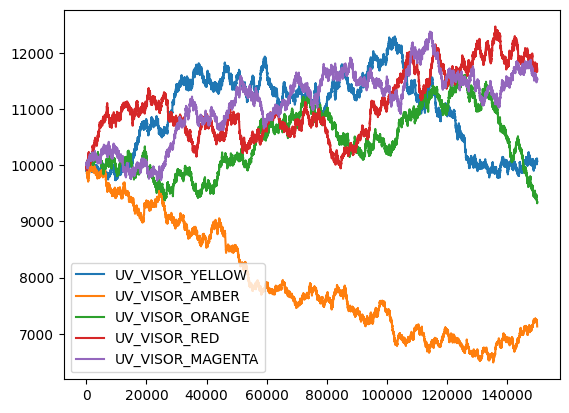

In [2]:
for p in colors:
    plt.plot(prices[prices['product'] == p]['mid_price'], label=p)
plt.legend()
plt.show()

Circle - Oval

Square - Rectangle

In [3]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

<Axes: title={'center': 'Average mid across all UVs'}, xlabel='timestamp'>

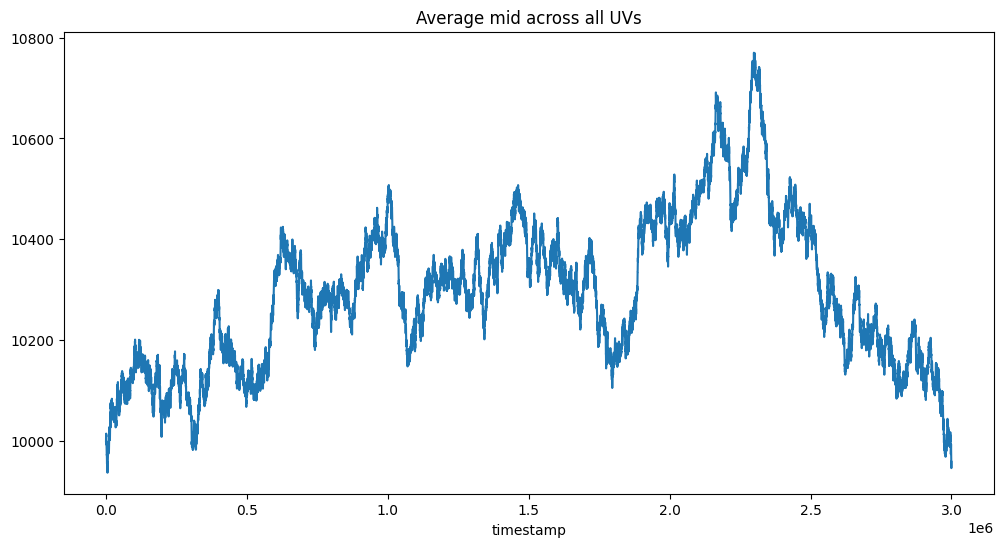

In [4]:
mids["UV_avg"] = mids[colors].mean(axis=1)
mids["UV_avg"].plot(figsize=(12, 6), title="Average mid across all UVs")

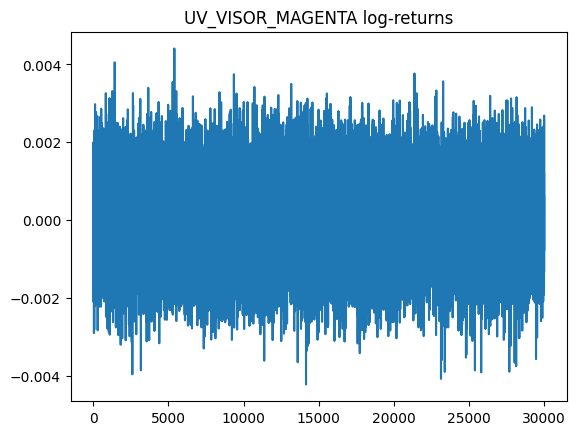

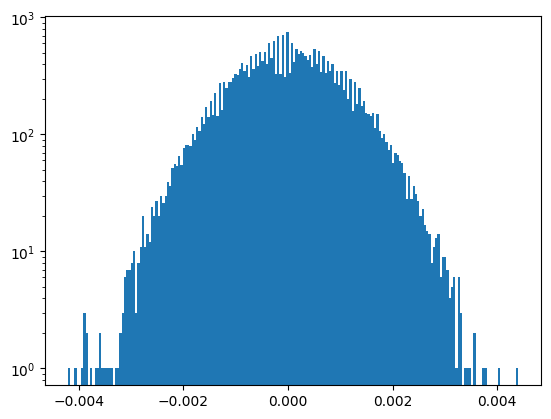

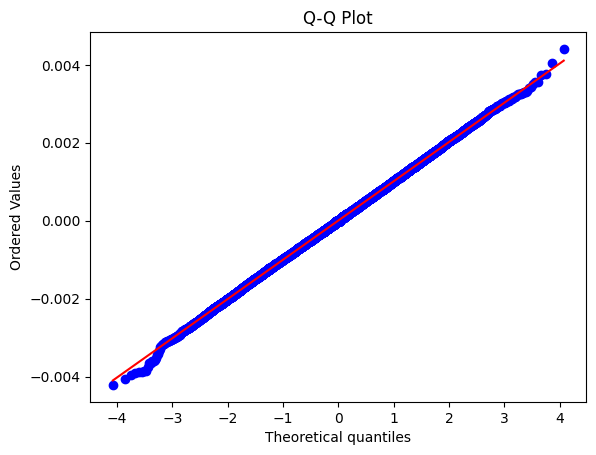

In [9]:
for s in colors[4:5]:
    log_ret = np.diff(np.log(mids[s]))
    plt.plot(log_ret)
    plt.title(f'{s} log-returns')
    plt.show()
    # Also look at the distribution
    plt.hist(log_ret, bins=200)
    plt.yscale('log')  # log scale to see tail behavior
    plt.show()
    stats.probplot(log_ret, dist="norm", plot=plt)
    plt.title('Q-Q Plot')

In [10]:
def estimate_gbm_params(prices, dt=1.0):
    """
    prices: price level series
    dt: time step size (1.0 if returns are already per-tick)
    """
    log_ret = np.diff(np.log(prices))
    n = len(log_ret)
    
    # MLE estimates
    mu_ret = np.mean(log_ret)       # mean log-return per tick
    sigma2 = np.var(log_ret, ddof=1) # variance of log-returns
    sigma = np.sqrt(sigma2 / dt)     # volatility per unit time
    
    # Drift of the price process (Ito correction)
    mu = mu_ret / dt + 0.5 * sigma2 / dt  # drift of S, not log(S)
    
    # Standard errors
    se_mu_ret = np.sqrt(sigma2 / n)
    se_sigma = sigma / np.sqrt(2 * (n-1))
    
    # t-stat for drift being nonzero
    t_stat = mu_ret / se_mu_ret
    
    return {
        'mu_log': mu_ret,        # mean log-return per tick
        'mu': mu,                # drift of price process
        'sigma': sigma,          # volatility
        'se_mu': se_mu_ret,      # std error of mean log-return
        'se_sigma': se_sigma,    # std error of sigma
        't_stat_drift': t_stat,  # is drift significantly nonzero?
    }

for asset in colors:
    params = estimate_gbm_params(mids[asset])
    print(f"{asset}: mu_log={params['mu_log']:.6f} "
          f"(t={params['t_stat_drift']:.2f}) "
          f"sigma={params['sigma']:.6f}")

UV_VISOR_YELLOW: mu_log=0.000000 (t=0.04) sigma=0.001002
UV_VISOR_AMBER: mu_log=-0.000011 (t=-1.94) sigma=0.001006
UV_VISOR_ORANGE: mu_log=-0.000002 (t=-0.39) sigma=0.001002
UV_VISOR_RED: mu_log=0.000005 (t=0.92) sigma=0.000996
UV_VISOR_MAGENTA: mu_log=0.000005 (t=0.82) sigma=0.001007


In [11]:
from statsmodels.tsa.stattools import coint
import itertools

for a1, a2 in itertools.combinations(colors, 2):
    pval = coint(mids[a1], mids[a2])[1]
    print(f"{a1} vs {a2}: p={pval:.4f}")
    # p < 0.05 means cointegrated → pairs trade

UV_VISOR_YELLOW vs UV_VISOR_AMBER: p=0.8295
UV_VISOR_YELLOW vs UV_VISOR_ORANGE: p=0.7836
UV_VISOR_YELLOW vs UV_VISOR_RED: p=0.2773
UV_VISOR_YELLOW vs UV_VISOR_MAGENTA: p=0.8385
UV_VISOR_AMBER vs UV_VISOR_ORANGE: p=0.8255
UV_VISOR_AMBER vs UV_VISOR_RED: p=0.6603
UV_VISOR_AMBER vs UV_VISOR_MAGENTA: p=0.0776
UV_VISOR_ORANGE vs UV_VISOR_RED: p=0.9007
UV_VISOR_ORANGE vs UV_VISOR_MAGENTA: p=0.7795
UV_VISOR_RED vs UV_VISOR_MAGENTA: p=0.5809
